In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
D = pd.read_csv("data/gr17.csv", sep=',', header=None).to_numpy()

print(D)


[[  0 633 257  91 412 150  80 134 259 505 353 324  70 211 268 246 121]
 [633   0 390 661 227 488 572 530 555 289 282 638 567 466 420 745 518]
 [257 390   0 228 169 112 196 154 372 262 110 437 191  74  53 472 142]
 [ 91 661 228   0 383 120  77 105 175 476 324 240  27 182 239 237  84]
 [412 227 169 383   0 267 351 309 338 196  61 421 346 243 199 528 297]
 [150 488 112 120 267   0  63  34 264 360 208 329  83 105 123 364  35]
 [ 80 572 196  77 351  63   0  29 232 444 292 297  47 150 207 332  29]
 [134 530 154 105 309  34  29   0 249 402 250 314  68 108 165 349  36]
 [259 555 372 175 338 264 232 249   0 495 352  95 189 326 383 202 236]
 [505 289 262 476 196 360 444 402 495   0 154 578 439 336 240 685 390]
 [353 282 110 324  61 208 292 250 352 154   0 435 287 184 140 542 238]
 [324 638 437 240 421 329 297 314  95 578 435   0 254 391 448 157 301]
 [ 70 567 191  27 346  83  47  68 189 439 287 254   0 145 202 289  55]
 [211 466  74 182 243 105 150 108 326 336 184 391 145   0  57 426  96]
 [268 

In [6]:
import numpy as np

class ACO():
    def __init__(self, strategy='global', alpha=1.0, beta=2.0):
        self.best_road = None
        self.best_dist = float('inf')
        self.alpha = alpha
        self.beta = beta
        
        # Mapeo de estrategias de depósito
        strategies = {
            'global': self._global_deposit,
            'local': self._local_deposit,
            'uniform': self._uniform_deposit
        }
        
        if strategy not in strategies:
            raise ValueError(f"Estrategia '{strategy}' no válida.")
        self._deposit = strategies[strategy]

    def run(self, rho, D, n_ants, max_iters):
        n_cities = D.shape[0]
        # Evitar división por cero en la visibilidad (heurística eta)
        with np.errstate(divide='ignore'):
            eta = 1.0 / D
            eta[np.isinf(eta)] = 0
            
        # Inicialización de feromonas
        tau = np.random.uniform(0.1, 0.5, size=(n_cities, n_cities))

        for t in range(max_iters):
            # Construcción de caminos vectorizada (todas las hormigas a la vez)
            roads = self._build_paths(n_ants, n_cities, tau, eta)
            
            # Cálculo de distancias vectorizado
            distances = self._calculate_distances(roads, D)

            # Actualización de la mejor solución histórica
            min_idx = np.argmin(distances)
            if distances[min_idx] < self.best_dist:
                self.best_dist = distances[min_idx]
                self.best_road = roads[min_idx].copy()

            # Evaporación y depósito
            tau *= (1 - rho)
            self._deposit(roads, distances, tau)

        return self.best_road, self.best_dist

    def _build_paths(self, n_ants, n_cities, tau, eta):
        roads = np.zeros((n_ants, n_cities + 1), dtype=int)
        visited_mask = np.zeros((n_ants, n_cities), dtype=bool)
        
        # Todas inician en la ciudad 0
        current_nodes = np.zeros(n_ants, dtype=int)
        visited_mask[:, 0] = True
        
        # Pre-calculamos la potencia de las feromonas y visibilidad
        # Esto reduce cálculos repetitivos dentro del bucle de pasos
        tau_alpha = np.power(tau, self.alpha)
        eta_beta = np.power(eta, self.beta)
        combined_influence = tau_alpha * eta_beta

        for step in range(1, n_cities):
            # 1. Obtener fila de influencia para los nodos actuales de cada hormiga
            probs = combined_influence[current_nodes, :]
            
            # 2. Aplicar máscara: probabilidad 0 a ciudades ya visitadas
            probs[visited_mask] = 0
            
            # 3. Normalizar probabilidades por fila
            row_sums = probs.sum(axis=1, keepdims=True)
            # Manejo de seguridad para filas con suma cero
            probs = np.divide(probs, row_sums, out=np.zeros_like(probs), where=row_sums != 0)
            
            # 4. Muestreo vectorizado (Ruleta Rusa simultánea)
            cumulative_probs = probs.cumsum(axis=1)
            r = np.random.rand(n_ants, 1)
            next_nodes = (r < cumulative_probs).argmax(axis=1)
            
            # 5. Registrar paso y actualizar estado
            roads[:, step] = next_nodes
            visited_mask[np.arange(n_ants), next_nodes] = True
            current_nodes = next_nodes
            
        # Regreso al origen (ciudad 0)
        roads[:, -1] = 0
        return roads

    def _calculate_distances(self, roads, D):
        # Indexación avanzada para obtener todos los costos de los tramos
        # roads[:, :-1] son los orígenes, roads[:, 1:] son los destinos
        return D[roads[:, :-1], roads[:, 1:]].sum(axis=1)

    def _global_deposit(self, roads, distances, tau):
        # Todas las hormigas dejan feromona: delta = 1 / distancia_total
        delta_tau = 1.0 / distances
        self._atomic_add(tau, roads, delta_tau)

    def _local_deposit(self, roads, distances, tau):
        # Solo la mejor de la iteración actual deposita
        best_idx = np.argmin(distances)
        best_road = roads[best_idx : best_idx + 1]
        delta_tau = np.array([1.0 / distances[best_idx]])
        self._atomic_add(tau, best_road, delta_tau)

    def _uniform_deposit(self, roads, distances, tau, constant=1.0):
        # Todas depositan una cantidad fija
        delta_tau = np.full(roads.shape[0], constant)
        self._atomic_add(tau, roads, delta_tau)

    def _atomic_add(self, tau, roads, delta_tau):
        """Aplica incrementos a la matriz de feromonas de forma atómica."""
        from_nodes = roads[:, :-1].flatten()
        to_nodes = roads[:, 1:].flatten()
        
        # Repetir el valor de delta para cada tramo del camino (n_cities tramos)
        n_steps = roads.shape[1] - 1
        increments = np.repeat(delta_tau, n_steps)
        
        # np.add.at es necesario para manejar colisiones (múltiples hormigas en un arco)
        np.add.at(tau, (from_nodes, to_nodes), increments)
        np.add.at(tau, (to_nodes, from_nodes), increments)

In [7]:
aco = ACO(strategy = 'uniform')
mejor_camino, mejor_distancia = aco.run(rho=0.1, D=D, n_ants=17, max_iters=100)

print(f"Mejor distancia: {mejor_distancia}")
print(f"Mejor camino: {mejor_camino}")

Mejor distancia: 2094
Mejor camino: [ 0 12  3  6  7  5 16 13 14  2 10  9  1  4  8 11 15  0]


# Analisis de hiperparametros
Para esta etapa lo que vamos a hacer es ver el efecto que tiene la tasa de evaporación y la cantidad de feromona depositada sobre los resultados de la busqueda 

In [8]:
import time
rho_s= [0.1, 0.3, 0.5, 0.7, 0.9]

strategies = ['global', 'local', 'uniform']
n_rep = 15

results = {}

for rho in rho_s:
    results[rho]={}
    
    for strategy in strategies:
        aux_dict ={}
        bests_dists = []
        bests_times =[]
        bests_roads = []
        for _ in range(n_rep):
            
            init_time = time.time()
            aco = ACO(strategy = strategy)
            best_road, best_dist = aco.run(rho=rho, D=D, n_ants = 17, max_iters = 200)
            end_time = time.time()

            bests_dists.append(best_dist)
            bests_times.append(end_time - init_time)
            bests_roads.append(best_road)

        results[rho][strategy] = {
            'best_road': bests_roads,
            'best_dist': bests_dists,
            'best_time': bests_times
        }

print(results)

{0.1: {'global': {'best_road': [array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  4,  1,  9,  8, 11, 15,
        0]), array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0, 12,  3,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0, 12,  3,  6, 16,  5,  7, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0, 12,  3, 16,  6,  7,  5, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0, 12,  3,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0, 12,  3,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  4,  1,  9,  8, 11, 15,
        0]), array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  4,  1,  9,  8, 11, 15,
        0]), array([ 0,  3, 12,  6,  7,  5, 16, 13, 14,  2, 10,  9,  1,  4,  8, 11, 15,
        0]), 

In [10]:
data_rows = []

for rho in rho_s:
    for strategy in strategies:
        distancias = results[rho][strategy]['best_dist']
        tiempos = results[rho][strategy]['best_time']
        
        # Calcular estadísticas
        data_rows.append({
            'ρ': rho,
            'Estrategia': strategy,
            'Distancia media': np.mean(distancias),
            'Distancia std': np.std(distancias),
            'Tiempo medio (s)': np.mean(tiempos),
            'Tiempo std (s)': np.std(tiempos),
            'Mejor distancia': np.min(distancias),
            'Peor distancia': np.max(distancias)
        })

# Crear DataFrame
df_stats = pd.DataFrame(data_rows)

# Redondear para mejor visualización
df_stats = df_stats.round({
    'Distancia media': 2,
    'Distancia std': 2,
    'Tiempo medio (s)': 4,
    'Tiempo std (s)': 4,
    'Mejor distancia': 2,
    'Peor distancia': 2
})

display(df_stats)

,ρ,Estrategia,Distancia media,Distancia std,Tiempo medio (s),Tiempo std (s),Mejor distancia,Peor distancia
0,0.1,global,2108.00,23.55,0.0870,0.0190,2085,2149
1,0.1,local,2113.93,33.96,0.0820,0.0054,2085,2181
2,0.1,uniform,2112.20,23.26,0.0789,0.0055,2085,2152
3,0.3,global,2126.60,24.15,0.0809,0.0068,2094,2152
4,0.3,local,2145.47,25.65,0.0841,0.0242,2094,2181
5,0.3,uniform,2135.67,26.14,0.0767,0.0042,2088,2178
6,0.5,global,2130.73,30.62,0.0852,0.0053,2094,2178
7,0.5,local,2157.07,31.78,0.0880,0.0229,2085,2214
8,0.5,uniform,2148.73,21.13,0.0770,0.0052,2094,2178
9,0.7,global,2146.93,29.14,0.0810,0.0084,2085,2178


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19208\3167954715.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_19208\3167954715.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_19208\3167954715.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot_time, x='Estrategia', y=

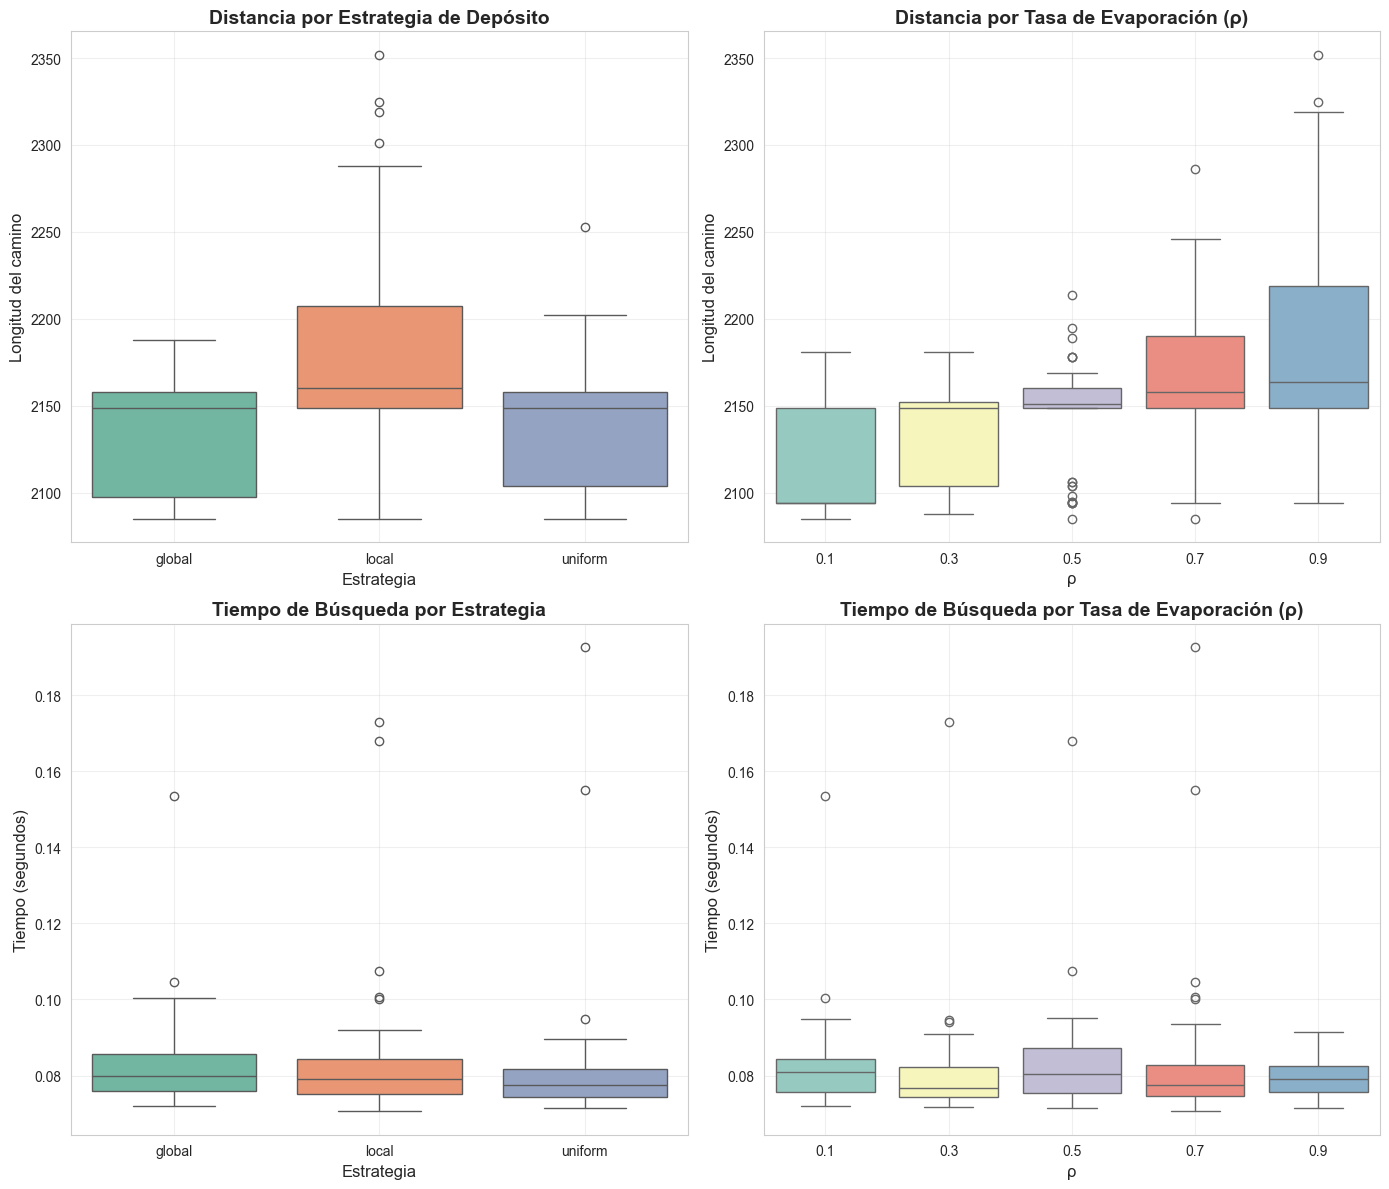

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Primero, preparar los datos para los boxplots de DISTANCIA
data_boxplot_dist = []

for rho in results:
    for strategy in results[rho]:
        distancias = results[rho][strategy]['best_dist']
        for dist in distancias:
            data_boxplot_dist.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Distancia': dist
            })

df_boxplot_dist = pd.DataFrame(data_boxplot_dist)

# Preparar los datos para los boxplots de TIEMPO
data_boxplot_time = []

for rho in results:
    for strategy in results[rho]:
        tiempos = results[rho][strategy]['best_time']
        for t in tiempos:
            data_boxplot_time.append({
                'ρ': rho,
                'Estrategia': strategy,
                'Tiempo': t
            })

df_boxplot_time = pd.DataFrame(data_boxplot_time)

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 12)

# Crear figura con subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Distancia por Estrategia
sns.boxplot(data=df_boxplot_dist, x='Estrategia', y='Distancia', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distancia por Estrategia de Depósito', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Estrategia', fontsize=12)
axes[0, 0].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Distancia por ρ
sns.boxplot(data=df_boxplot_dist, x='ρ', y='Distancia', ax=axes[0, 1], palette='Set3')
axes[0, 1].set_title('Distancia por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('ρ', fontsize=12)
axes[0, 1].set_ylabel('Longitud del camino', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Tiempo por Estrategia
sns.boxplot(data=df_boxplot_time, x='Estrategia', y='Tiempo', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Tiempo de Búsqueda por Estrategia', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Estrategia', fontsize=12)
axes[1, 0].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Tiempo por ρ
sns.boxplot(data=df_boxplot_time, x='ρ', y='Tiempo', ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Tiempo de Búsqueda por Tasa de Evaporación (ρ)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('ρ', fontsize=12)
axes[1, 1].set_ylabel('Tiempo (segundos)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()